# PRODIGY_DS_01 — Distribution of a Categorical/Continuous Variable
**Task:** Create a bar chart or histogram to visualize the distribution of a categorical or continuous variable, such as the distribution of ages or genders in a population.

**Dataset:** [World Bank — World Development Indicators, Population Total (SP.POP.TOTL)](https://github.com/Prodigy-InfoTech/data-science-datasets/tree/main/Task%201) — total population by country, 1960–2024.

**Author:** Divyanshi Shukla

---
### Approach
1. Load the raw World Bank export and its country metadata.
2. Clean: remove the 49 aggregate/regional rollup rows (e.g. "World", "High income") that the World Bank mixes in with actual countries, drop unusable columns, check for duplicates/missing values.
3. Visualize the **continuous** variable (population) with a histogram — on both raw and log scale, since population is extremely right-skewed.
4. Visualize the **categorical** breakdown (country, region, income group) with bar charts and a boxplot.
5. Summarize the insights a hiring manager would actually want to see.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
PALETTE = "crest"
LATEST_YEAR = "2024"
pd.set_option("display.max_columns", 10)

## 1. Load the data

In [2]:
# World Bank CSV exports have 4 metadata lines before the real header row
pop = pd.read_csv("data/world_population.csv", skiprows=4)
meta = pd.read_csv("data/metadata_country.csv")

print(pop.shape)
pop.head(3)

(266, 70)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,...,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,...,107700.0,107310.0,107359.0,107624.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,...,713090928.0,731821393.0,750503764.0,769294618.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,...,40000412.0,40578842.0,41454761.0,42647492.0,NaN


## 2. Data cleaning

In [3]:
# Drop the trailing empty column the World Bank always exports
pop = pop.loc[:, ~pop.columns.str.startswith("Unnamed")]

# The file mixes 217 real countries with 49 aggregate rows (World, High income,
# East Asia & Pacific, ...). Aggregates have no Region in the metadata table,
# so an inner join + dropna isolates the real countries only.
df = pop.merge(meta[["Country Code", "Region", "IncomeGroup"]], on="Country Code", how="inner")
df = df[df["Region"].notna()].copy()

print("Duplicate country codes:", df.duplicated(subset="Country Code").sum())
print("Missing", LATEST_YEAR, "values:", df[LATEST_YEAR].isna().sum())

df = df.dropna(subset=[LATEST_YEAR]).copy()
df[LATEST_YEAR] = df[LATEST_YEAR].astype(float)
df["Population (millions)"] = df[LATEST_YEAR] / 1_000_000

print(f"Final dataset: {len(df)} countries")
df[["Country Name", "Region", "IncomeGroup", LATEST_YEAR]].sample(5, random_state=1)

Duplicate country codes: 0
Missing 2024 values: 0
Final dataset: 217 countries


,Country Name,Region,IncomeGroup,2024
91,Greenland,Europe & Central Asia,High income,56836.0
37,Switzerland,Europe & Central Asia,High income,9034102.0
38,Channel Islands,Europe & Central Asia,High income,168126.0
75,Finland,Europe & Central Asia,High income,5637214.0
117,Jordan,"Middle East, North Africa, Afghanistan & Pakistan",Lower middle income,11552876.0


## 3. Distribution of the continuous variable — Population (Histogram)

Population is heavily right-skewed (a handful of countries — China, India — dwarf the rest), so it's
plotted on both a raw and a log10 scale. The log scale reveals the underlying shape much more clearly.

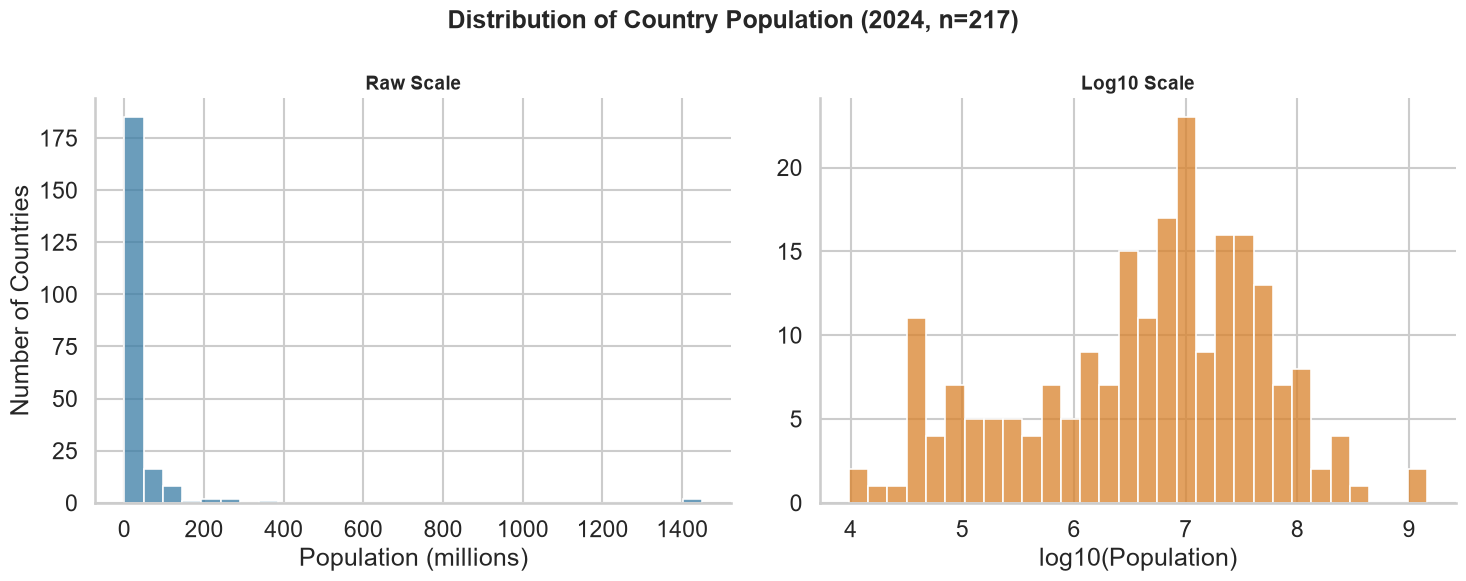

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df["Population (millions)"], bins=30, color="#3A7CA5", ax=axes[0], edgecolor="white")
axes[0].set_title("Raw Scale", fontsize=14, weight="bold")
axes[0].set_xlabel("Population (millions)")
axes[0].set_ylabel("Number of Countries")

sns.histplot(np.log10(df[LATEST_YEAR]), bins=30, color="#D9822B", ax=axes[1], edgecolor="white")
axes[1].set_title("Log10 Scale", fontsize=14, weight="bold")
axes[1].set_xlabel("log10(Population)")
axes[1].set_ylabel("")

fig.suptitle(f"Distribution of Country Population ({LATEST_YEAR}, n={len(df)})", fontsize=18, weight="bold")
sns.despine()
plt.tight_layout()
plt.savefig("outputs/02_population_histogram.png", dpi=150)
plt.show()

In [5]:
skew = df[LATEST_YEAR].skew()
print(f"Mean population   : {df[LATEST_YEAR].mean()/1e6:,.1f}M")
print(f"Median population : {df[LATEST_YEAR].median()/1e6:,.1f}M")
print(f"Skewness           : {skew:.2f}  (0 = symmetric; this is heavily right-skewed)")

Mean population   : 37.4M
Median population : 6.6M
Skewness           : 8.78  (0 = symmetric; this is heavily right-skewed)


## 4. Distribution of the categorical variable — Top Countries (Bar Chart)

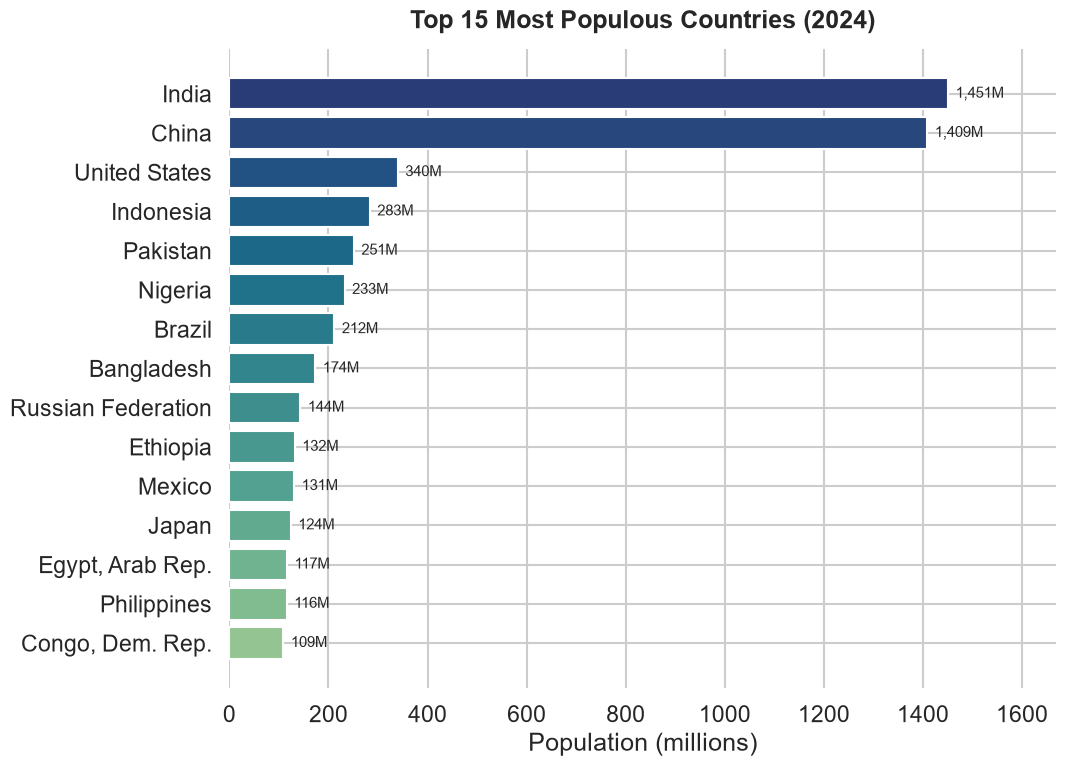

In [6]:
top15 = df.nlargest(15, LATEST_YEAR).sort_values(LATEST_YEAR)

fig, ax = plt.subplots(figsize=(11, 8))
colors = sns.color_palette(PALETTE, len(top15))
bars = ax.barh(top15["Country Name"], top15["Population (millions)"], color=colors)

for bar, val in zip(bars, top15["Population (millions)"]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2, f"{val:,.0f}M", va="center", fontsize=11)

ax.set_xlabel("Population (millions)")
ax.set_title(f"Top 15 Most Populous Countries ({LATEST_YEAR})", fontsize=18, weight="bold", pad=15)
ax.set_xlim(0, top15["Population (millions)"].max() * 1.15)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("outputs/01_top15_countries_bar.png", dpi=150)
plt.show()

## 5. Population by Region (Bar Chart)

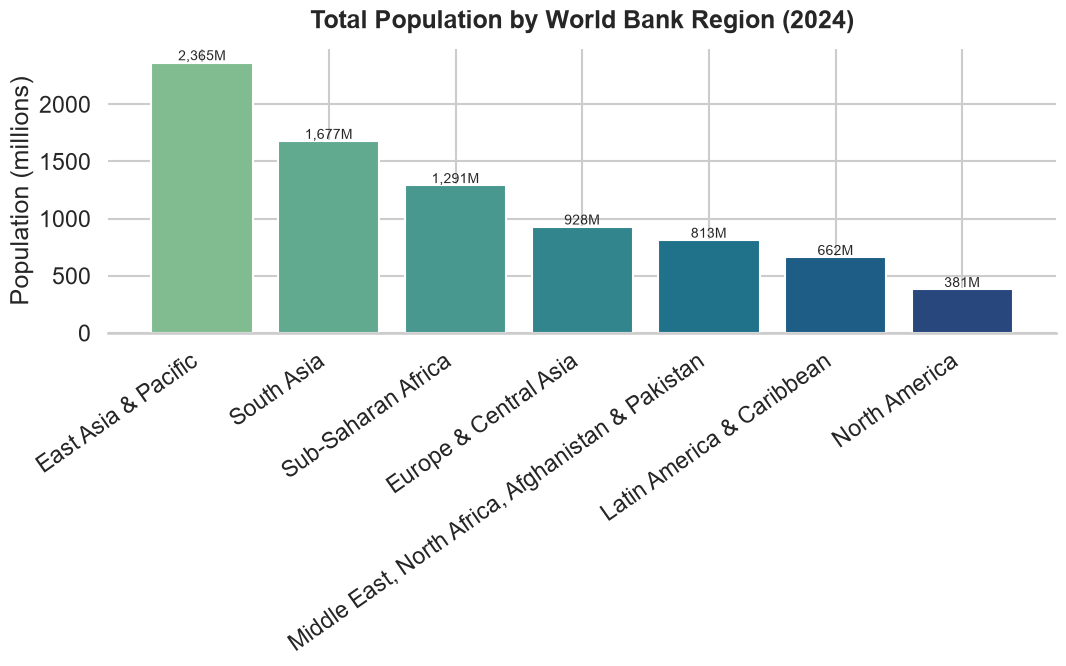

In [7]:
region_totals = df.groupby("Region")[LATEST_YEAR].sum().sort_values(ascending=False) / 1_000_000

fig, ax = plt.subplots(figsize=(11, 7))
colors = sns.color_palette(PALETTE, len(region_totals))
bars = ax.bar(region_totals.index, region_totals.values, color=colors)

for bar, val in zip(bars, region_totals.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 20, f"{val:,.0f}M", ha="center", fontsize=10)

ax.set_ylabel("Population (millions)")
ax.set_title(f"Total Population by World Bank Region ({LATEST_YEAR})", fontsize=18, weight="bold", pad=15)
plt.xticks(rotation=35, ha="right")
sns.despine(left=True)
plt.tight_layout()
plt.savefig("outputs/03_population_by_region_bar.png", dpi=150)
plt.show()

## 6. Bonus — Population Spread by Income Group (Boxplot)

A quick look at whether "developed" vs "developing" status (World Bank income group) relates to population size.

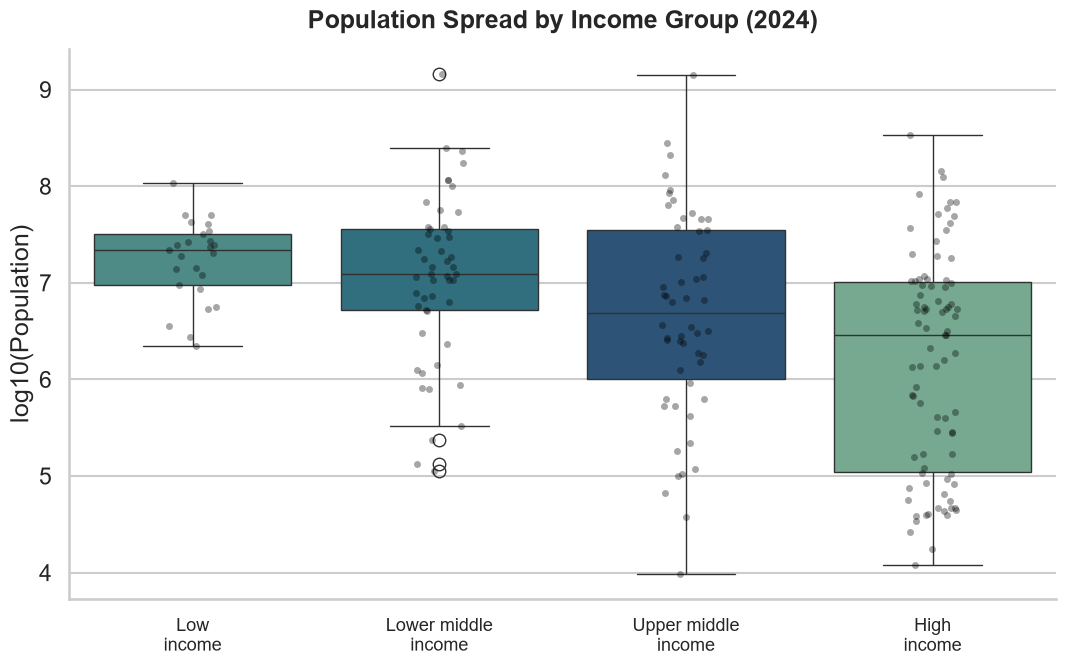

In [8]:
order = ["Low income", "Lower middle income", "Upper middle income", "High income"]
d = df[df["IncomeGroup"].isin(order)].copy()
d["log_pop"] = np.log10(d[LATEST_YEAR])

fig, ax = plt.subplots(figsize=(11, 7))
sns.boxplot(data=d, x="IncomeGroup", y="log_pop", hue="IncomeGroup", order=order,
            palette=PALETTE, legend=False, ax=ax)
sns.stripplot(data=d, x="IncomeGroup", y="log_pop", order=order, color="black", alpha=0.35, ax=ax)

ax.set_ylabel("log10(Population)")
ax.set_xlabel("")
ax.set_title(f"Population Spread by Income Group ({LATEST_YEAR})", fontsize=18, weight="bold", pad=15)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([lbl.replace(" income", "\nincome") for lbl in order], fontsize=13)
sns.despine()
plt.tight_layout()
plt.savefig("outputs/04_population_by_income_group.png", dpi=150)
plt.show()

## 7. Key Insights

- **217 countries** were analyzed after removing 49 World Bank regional/income aggregates from the raw file.
- The distribution of population across countries is **heavily right-skewed** (skewness ≈ 8.8): a few countries hold enormous shares while most are comparatively small.
- **India (1.45B) and China (1.41B)** together account for roughly **35%** of the entire world's population, despite being just 2 of 217 countries (< 1%).
- The **median** country has a population of only ~6.6M — over 5x smaller than the **mean** of ~37M — confirming the distribution is dominated by outliers rather than being "typical."
- On a log scale, the distribution looks close to log-normal — a common pattern for quantities (population, wealth, city size) shaped by multiplicative growth processes.
- **East Asia & Pacific** and **South Asia** are the most populous World Bank regions, together holding roughly half of the world's people.
- Population size doesn't cleanly track income group — some of the largest low/lower-middle income countries (India, Nigeria, Pakistan) rival high-income countries combined, while many high-income countries (Luxembourg, Iceland) are tiny by population.

### Tools used
`pandas` · `numpy` · `matplotlib` · `seaborn`